In [3]:
from google.colab import files
uploaded = files.upload()


Saving heards_full_dataset.csv to heards_full_dataset.csv


In [4]:
uploaded = files.upload()


Saving heards_structured_cleaned_07.csv to heards_structured_cleaned_07.csv


In [6]:
import pandas as pd

df_initial = pd.read_csv("heards_full_dataset.csv")
df_final = pd.read_csv("heards_structured_cleaned_07.csv")

print("Initial shape:", df_initial.shape)
print("Final shape:", df_final.shape)


Initial shape: (215400, 3)
Final shape: (195672, 14)


In [7]:

# Calculate % filled
total_rows = len(df_initial)
column_fill_percentage = (df_initial.count() / total_rows * 100).round(2)

# Display results
print("📊 Initial Dataset Column Fill Rates:")
for col in df_initial.columns:
    print(f"- {col}: {column_fill_percentage[col]}% filled")

print(f"\nTotal Rows: {total_rows}")
print(f"Column Names: {list(df_initial.columns)}")


📊 Initial Dataset Column Fill Rates:
- headline: 100.0% filled
- id: 100.0% filled
- updatedDate: 100.0% filled

Total Rows: 215400
Column Names: ['headline', 'id', 'updatedDate']


In [8]:
# Calculate % filled
total_rows = len(df_final)
column_fill_percentage = (df_final.count() / total_rows * 100).round(2)

# Display results
print("📊 Final Dataset Column Fill Rates:")
for col in df_final.columns:
    print(f"- {col}: {column_fill_percentage[col]}% filled")

print(f"\nTotal Rows: {total_rows}")
print(f"Column Names: {list(df_final.columns)}")


📊 Final Dataset Column Fill Rates:
- updatedDate: 100.0% filled
- start_date: 99.43% filled
- end_date: 99.27% filled
- action_type: 100.0% filled
- party: 91.15% filled
- price: 100.0% filled
- price_basis: 80.92% filled
- grade: 89.18% filled
- incoterm: 82.2% filled
- location: 82.74% filled
- volume_min: 61.09% filled
- volume_max: 61.09% filled
- frequency_tag: 60.76% filled
- headline: 100.0% filled

Total Rows: 195672
Column Names: ['updatedDate', 'start_date', 'end_date', 'action_type', 'party', 'price', 'price_basis', 'grade', 'incoterm', 'location', 'volume_min', 'volume_max', 'frequency_tag', 'headline']


# 📝 HEARDS Dataset: Initial vs Final Comparison Report

## 📉 Data Reduction Summary

| Metric                  | Initial Dataset | Final Dataset | % Retained | % Lost |
|-------------------------|------------------|----------------|------------|--------|
| Total Rows              | 215,400           | 195,672         | 90.85%     | 9.15%  |

> ⚠️ **Reason for Data Loss**:  
Many rows in the initial dataset were excluded during cleaning and filtering because they were *informational announcements* (e.g., “Platts monitoring...”) and lacked actionable trade data, making them unsuitable for downstream modeling or analysis.


---

### 📊 Column Overview – Final HEARDS Dataset

| Column          | Description |
|-----------------|-------------|
| `updatedDate`   | The date when the record was reported or updated. Used as the reference point for modeling other dates. |
| `start_date`    | Predicted start date of the action window, derived from the headline and `updatedDate`. |
| `end_date`      | Predicted end date of the action window, derived from the headline and `updatedDate`. |
| `action_type`   | Describes the nature of the market action (e.g., offer, raise, lower). |
| `party`         | The company or entity initiating the market action (e.g., VITOLSG, GLENCORESG). |
| `price`         | The quoted value (numeric) for the commodity being referenced in the headline. |
| **`price_basis`** | The market pricing reference used to define the quote (e.g., MOPS 380). Will be used in the next step to normalize the price. |
| `grade`         | The quality/type of commodity referenced, often a numerical value like 180 or 380. |
| `incoterm`      | Standardized shipping term (e.g., FOB) used to specify delivery terms. |
| `location`      | The reported trade or delivery location (e.g., Straits, Asia). |
| `volume_min`    | Minimum volume offered/requested in the transaction, if available. |
| `volume_max`    | Maximum volume offered/requested in the transaction, if available. |
| `frequency_tag` | The frequency or time window label (e.g., 5 Day, BalMnth) stated in the headline. |
| `headline`      | The original trade headline text describing the action. Used for all model training and parsing. |

---


📅 UpdatedDate Range:
- Earliest: 2017-06-15
- Latest:   2025-05-23
- Total Unique Dates: 2032


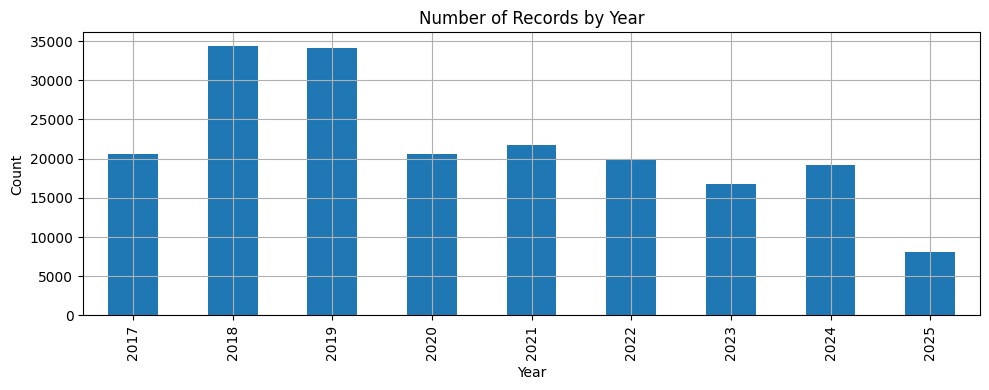

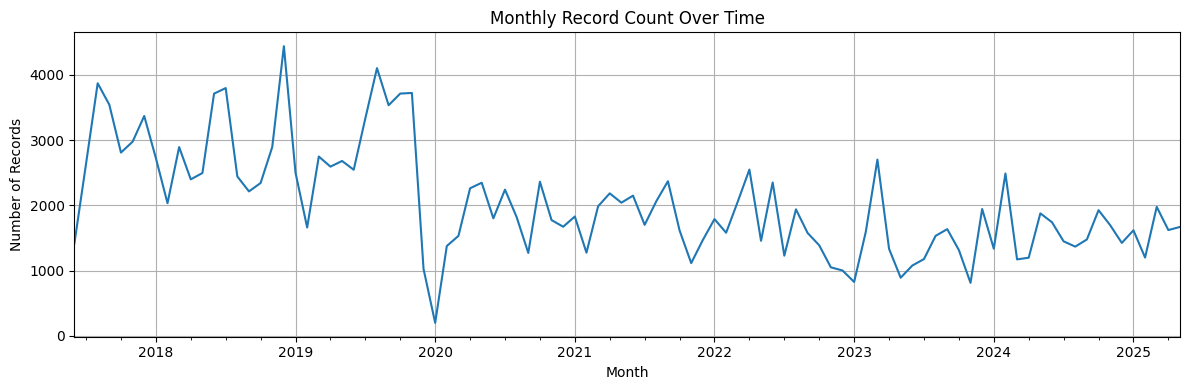

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("heards_structured_cleaned_07.csv")

# Convert to datetime (if not already)
df['updatedDate'] = pd.to_datetime(df['updatedDate'], errors='coerce')

# Drop nulls for plotting
df = df.dropna(subset=['updatedDate'])

# Summary stats
print("📅 UpdatedDate Range:")
print(f"- Earliest: {df['updatedDate'].min().date()}")
print(f"- Latest:   {df['updatedDate'].max().date()}")
print(f"- Total Unique Dates: {df['updatedDate'].nunique()}")

# Plot histogram by year
df['year'] = df['updatedDate'].dt.year

plt.figure(figsize=(10, 4))
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Records by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot monthly density
df['month'] = df['updatedDate'].dt.to_period('M')

plt.figure(figsize=(12, 4))
df['month'].value_counts().sort_index().plot(kind='line')
plt.title("Monthly Record Count Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.grid(True)
plt.tight_layout()
plt.show()


📅 Start Date Range: 2017-01-01 to 2025-12-29
📅 End Date Range: 2017-01-01 to 2025-12-31
📈 Avg. Time Window (days): 16


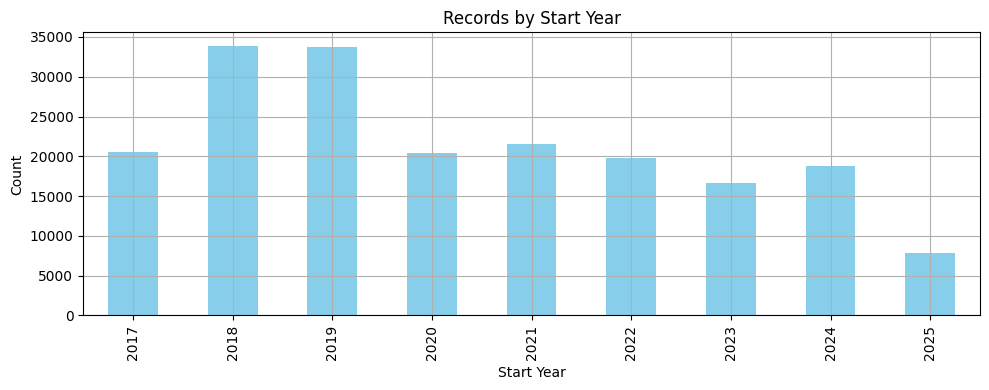

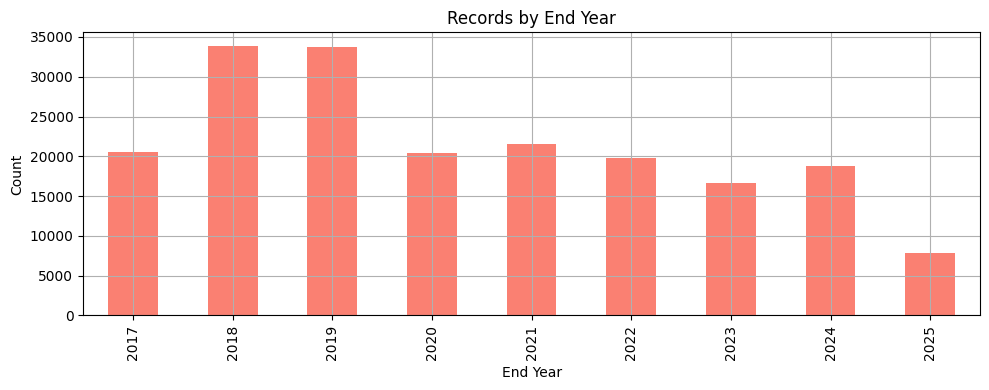

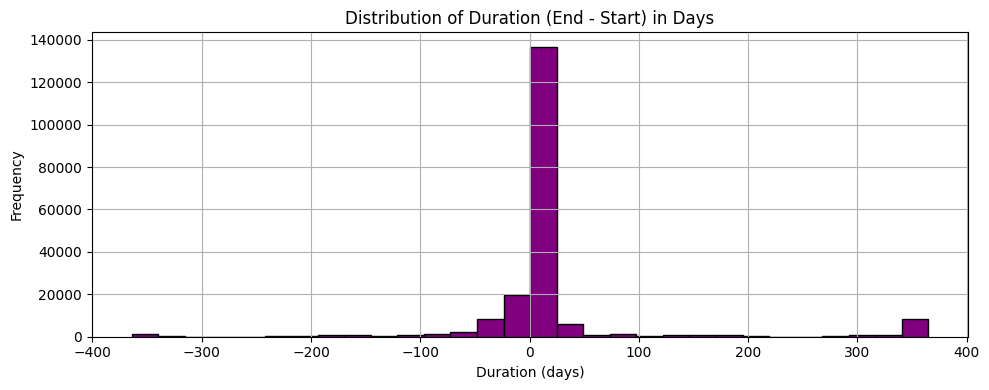

In [15]:
import matplotlib.pyplot as plt

# Convert to datetime
df_final['start_date'] = pd.to_datetime(df_final['start_date'], errors='coerce')
df_final['end_date'] = pd.to_datetime(df_final['end_date'], errors='coerce')

# Drop rows with missing start/end dates
df_dates = df_final.dropna(subset=['start_date', 'end_date']).copy()

# === Summary ===
print("📅 Start Date Range:", df_dates['start_date'].min().date(), "to", df_dates['start_date'].max().date())
print("📅 End Date Range:", df_dates['end_date'].min().date(), "to", df_dates['end_date'].max().date())
print("📈 Avg. Time Window (days):", (df_dates['end_date'] - df_dates['start_date']).mean().days)

# Add derived columns
df_dates['start_year'] = df_dates['start_date'].dt.year
df_dates['end_year'] = df_dates['end_date'].dt.year
df_dates['duration_days'] = (df_dates['end_date'] - df_dates['start_date']).dt.days

# === Plot 1: Count by Start Year ===
plt.figure(figsize=(10, 4))
df_dates['start_year'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Records by Start Year")
plt.xlabel("Start Year")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot 2: Count by End Year ===
plt.figure(figsize=(10, 4))
df_dates['end_year'].value_counts().sort_index().plot(kind='bar', color='salmon')
plt.title("Records by End Year")
plt.xlabel("End Year")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot 3: Distribution of Duration in Days ===
plt.figure(figsize=(10, 4))
df_dates['duration_days'].plot(kind='hist', bins=30, color='purple', edgecolor='black')
plt.title("Distribution of Duration (End - Start) in Days")
plt.xlabel("Duration (days)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


🔢 Action Type Counts:
action_type
Lower            61227
Raise            48268
Offer            35095
Bid              30162
No Trade         19789
Trade Summary     1131
Name: count, dtype: int64


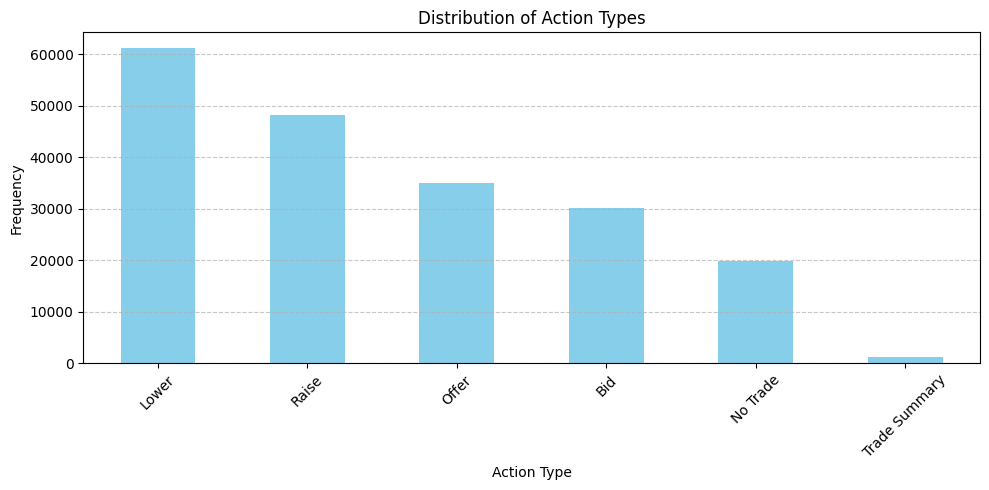

<ipython-input-17-af656fc3562e>:38: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


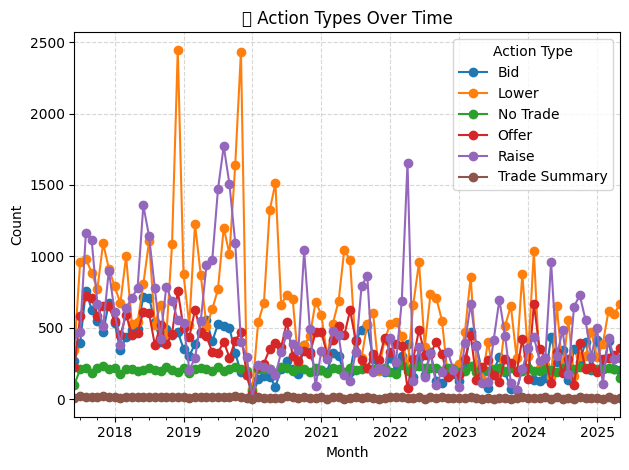

In [17]:
import matplotlib.pyplot as plt

# Count frequencies
action_counts = df['action_type'].value_counts()

# Display raw counts
print("🔢 Action Type Counts:")
print(action_counts)

# Bar plot
plt.figure(figsize=(10, 5))
action_counts.plot(kind='bar', color='skyblue')
plt.title("Distribution of Action Types")
plt.xlabel("Action Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Ensure datetime format
df['updatedDate'] = pd.to_datetime(df['updatedDate'], errors='coerce')

# Group by date and action_type
actions_over_time = df.groupby([df['updatedDate'].dt.to_period("M"), 'action_type']).size().unstack(fill_value=0)

# Convert PeriodIndex back to datetime for plotting
actions_over_time.index = actions_over_time.index.to_timestamp()

# Plot
plt.figure(figsize=(14, 6))
actions_over_time.plot(marker='o', linewidth=1.5)
plt.title("📈 Action Types Over Time")
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Action Type")
plt.tight_layout()
plt.show()



🏢 Top 10 Most Frequent Parties:
party
GLENCORESG    28554
VITOLSG       24373
TRAFI         24165
SIETCO        12501
GUNVORSG      12056
TOTALSG       11282
MERCURIASG     7804
P66SG          7484
HL             7061
PETROCHINA     6417
Name: count, dtype: int64


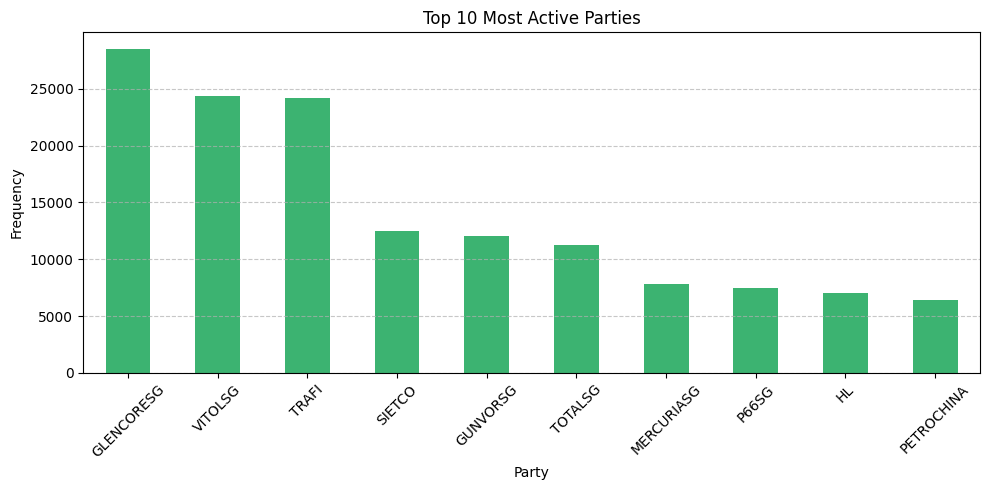

In [18]:
# Count the frequency of each party
party_counts = df['party'].value_counts().dropna()

# Display top 10
print("🏢 Top 10 Most Frequent Parties:")
print(party_counts.head(10))

# Bar plot of top 10
plt.figure(figsize=(10, 5))
party_counts.head(10).plot(kind='bar', color='mediumseagreen')
plt.title("Top 10 Most Active Parties")
plt.xlabel("Party")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


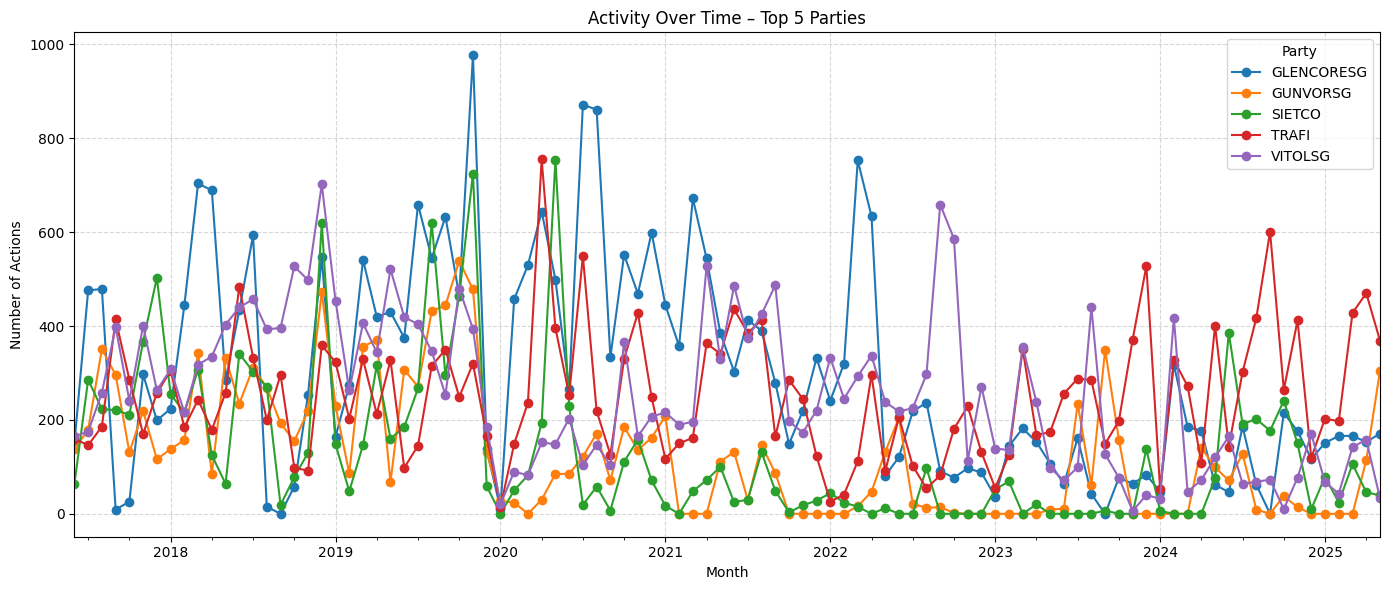

In [19]:
# Clean date
df['updatedDate'] = pd.to_datetime(df['updatedDate'], errors='coerce')

# Focus on top 5 parties
top_parties = party_counts.head(5).index
df_top_parties = df[df['party'].isin(top_parties)]

# Group by month and party
party_time = df_top_parties.groupby([df_top_parties['updatedDate'].dt.to_period("M"), 'party']).size().unstack(fill_value=0)
party_time.index = party_time.index.to_timestamp()

# Line plot
party_time.plot(figsize=(14, 6), marker='o', linewidth=1.5)
plt.title("Activity Over Time – Top 5 Parties")
plt.xlabel("Month")
plt.ylabel("Number of Actions")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Party")
plt.tight_layout()
plt.show()


💲 Price Summary Statistics:
count    195672.000000
mean        101.465608
std         153.449996
min        -122.748891
25%           2.000000
50%           7.000000
75%         289.687694
max         673.000000
Name: price, dtype: float64


<ipython-input-21-df666b9af2e1>:16: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


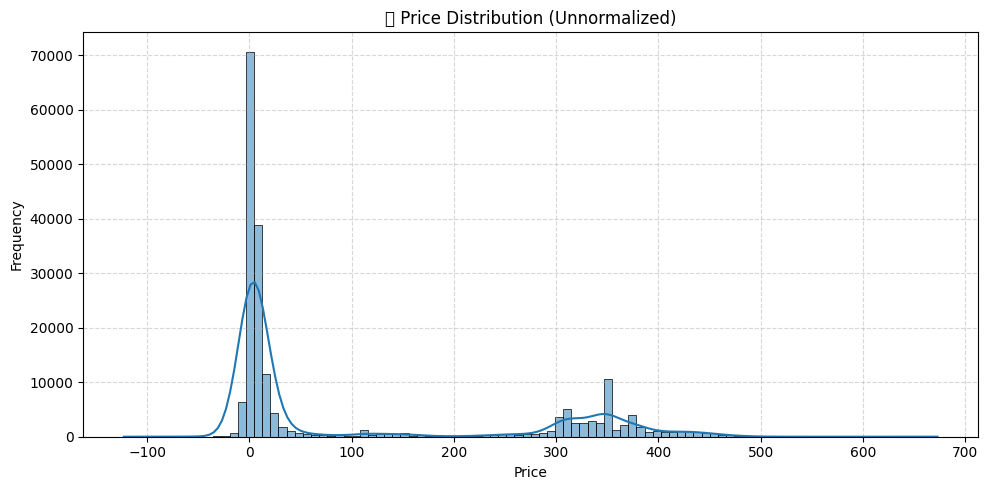

<ipython-input-21-df666b9af2e1>:23: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


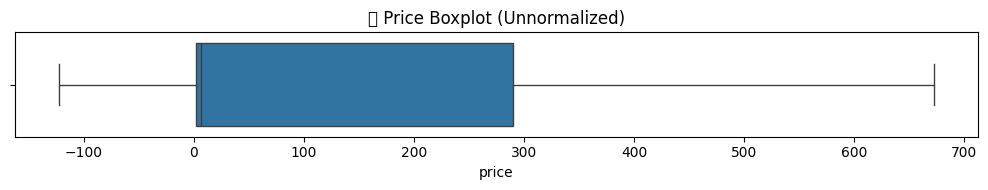

In [21]:
import seaborn as sns
# Drop nulls for price
price_series = df['price'].dropna()

# Summary stats
print("💲 Price Summary Statistics:")
print(price_series.describe())

# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(price_series, bins=100, kde=True)
plt.title("💰 Price Distribution (Unnormalized)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Boxplot to spot outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=price_series)
plt.title("📦 Price Boxplot (Unnormalized)")
plt.tight_layout()
plt.show()


🏷️ Top 10 Most Common Price Basis References:
price_basis
MOPS 380     116460
MOPS 180      37939
3              3816
MOPAG 380       104
F                13
MOPAG 180         3
Name: count, dtype: int64


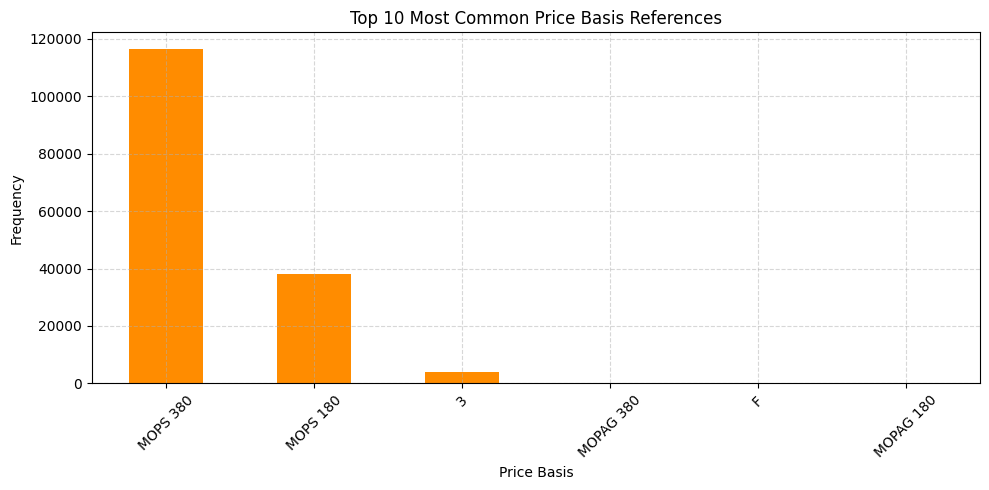

In [22]:
import matplotlib.pyplot as plt

# Drop missing
price_basis_counts = df['price_basis'].dropna().value_counts()

# Display top entries
print("🏷️ Top 10 Most Common Price Basis References:")
print(price_basis_counts.head(10))

# Bar chart
plt.figure(figsize=(10, 5))
price_basis_counts.head(10).plot(kind='bar', color='darkorange')
plt.title("Top 10 Most Common Price Basis References")
plt.xlabel("Price Basis")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


🛢️ Most Common Fuel Grades:
grade
180.0     46495
380.0    128007
Name: count, dtype: int64


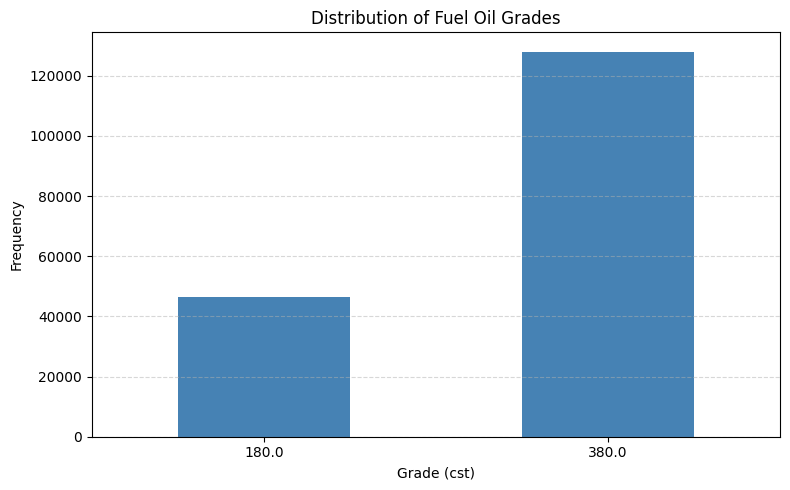

In [23]:
import matplotlib.pyplot as plt

# Drop nulls
grade_counts = df['grade'].dropna().value_counts().sort_index()

# Display top grades
print("🛢️ Most Common Fuel Grades:")
print(grade_counts)

# Bar chart
plt.figure(figsize=(8, 5))
grade_counts.plot(kind='bar', color='steelblue')
plt.title("Distribution of Fuel Oil Grades")
plt.xlabel("Grade (cst)")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [25]:
# Create cleaned price_basis column if it doesn't already exist
valid_basis = ['MOPS 380', 'MOPS 180']
df['price_basis_cleaned'] = df['price_basis'].where(df['price_basis'].isin(valid_basis), 'UNKNOWN')

# Cross-tab of grade and price_basis
cross_tab = pd.crosstab(df['grade'], df['price_basis_cleaned'])
print("\n🧾 Grade vs Price Basis:")
print(cross_tab)



🧾 Grade vs Price Basis:
price_basis_cleaned  MOPS 180  MOPS 380  UNKNOWN
grade                                           
180.0                   37014      3505     5976
380.0                     925    112955    14127


📦 Most Common Incoterms:
incoterm
FOB    158239
CIF      2611
Name: count, dtype: int64


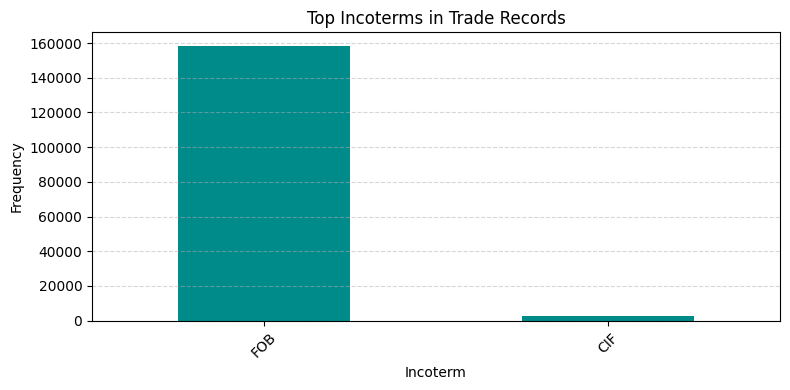

In [26]:
import matplotlib.pyplot as plt

# Drop missing values
incoterm_counts = df['incoterm'].dropna().value_counts()

# Display top incoterms
print("📦 Most Common Incoterms:")
print(incoterm_counts.head(10))

# Bar chart
plt.figure(figsize=(8, 4))
incoterm_counts.head(10).plot(kind='bar', color='darkcyan')
plt.title("Top Incoterms in Trade Records")
plt.xlabel("Incoterm")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [27]:
# See all unique incoterms
print("🔍 Unique incoterm values:")
print(sorted(df['incoterm'].dropna().unique()))


🔍 Unique incoterm values:
['CIF', 'FOB']


🗺️ Most Common Trade Locations:
location
Asia         80112
Straits      74515
Fujairah      5456
Malta         1809
Singapore        6
Name: count, dtype: int64


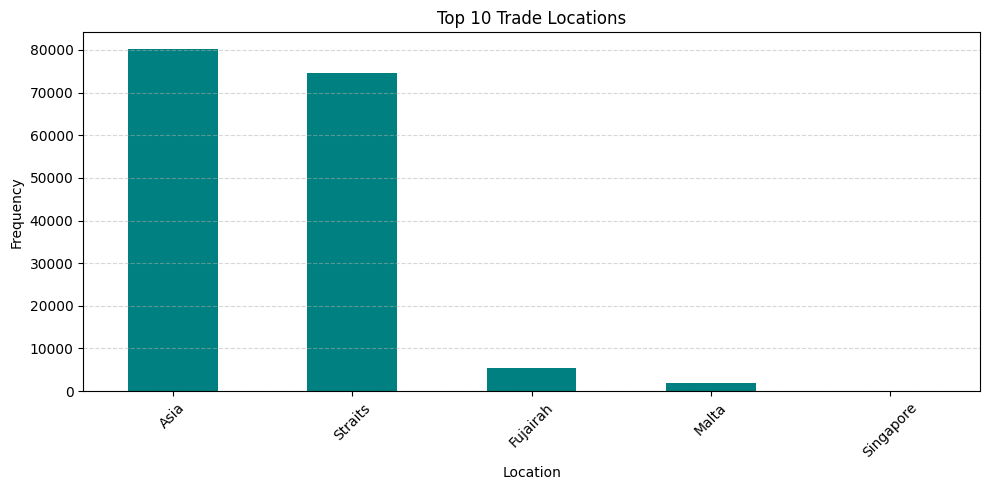

In [28]:
import matplotlib.pyplot as plt

# Drop missing
location_counts = df['location'].dropna().value_counts()

# Display top locations
print("🗺️ Most Common Trade Locations:")
print(location_counts.head(10))

# Bar chart
plt.figure(figsize=(10, 5))
location_counts.head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Trade Locations")
plt.xlabel("Location")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


<ipython-input-30-6d15ed488570>:44: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


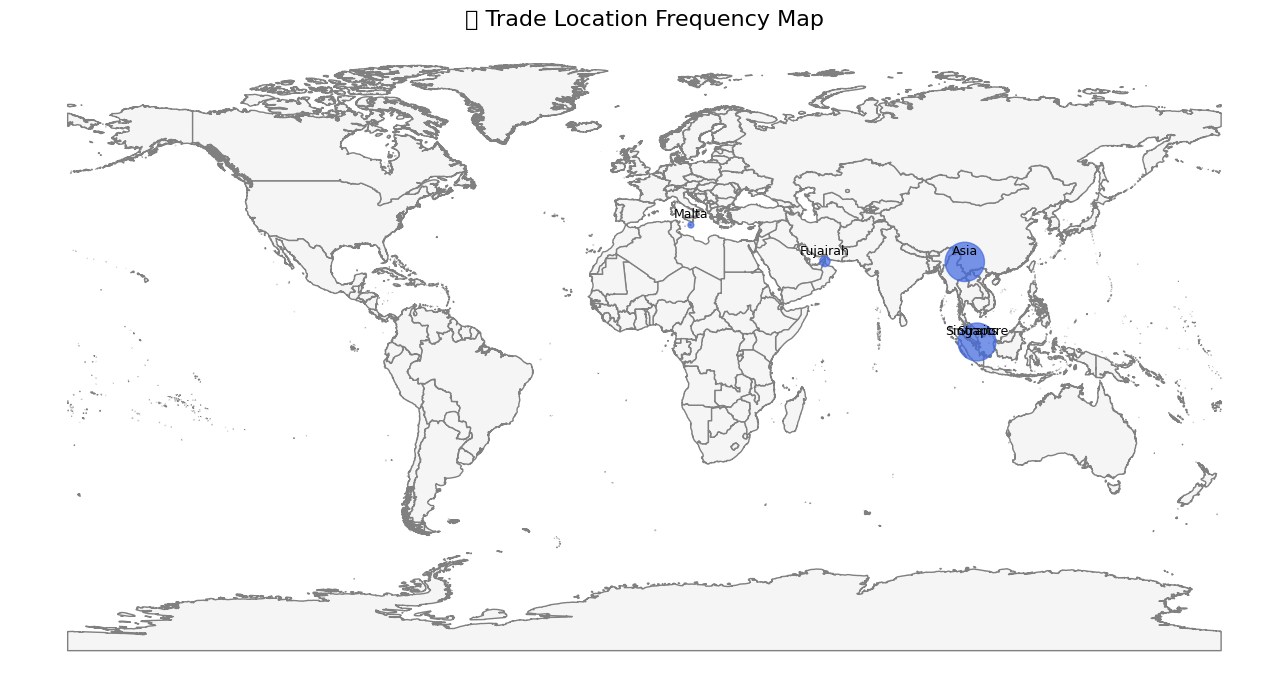

In [30]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Your manual location-to-coordinates mapping
location_coords = {
    "Asia": (100.0, 25.0),
    "Straits": (103.8, 1.3),
    "Fujairah": (56.345, 25.123),
    "Malta": (14.5146, 35.8997),
    "Singapore": (103.851959, 1.290270)
}

# Get top locations from your data
loc_freq = df['location'].value_counts().loc[location_coords.keys()]
location_df = pd.DataFrame({
    'location': loc_freq.index,
    'count': loc_freq.values,
    'lon': [location_coords[loc][0] for loc in loc_freq.index],
    'lat': [location_coords[loc][1] for loc in loc_freq.index]
})

# ✅ Use the Natural Earth low-res world map from public GeoJSON source
world = gpd.read_file("https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson")

# Build GeoDataFrame
gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(location_df.lon, location_df.lat),
    crs="EPSG:4326"
)

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
world.plot(ax=ax, color='whitesmoke', edgecolor='gray')
gdf.plot(ax=ax, color='royalblue', markersize=gdf['count'] / 100, alpha=0.7)

# Add text labels
for x, y, label in zip(gdf.lon, gdf.lat, gdf.location):
    ax.text(x, y + 2, label, fontsize=9, ha='center')

plt.title("🌍 Trade Location Frequency Map", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


In [31]:
# Summary stats
print("📈 Volume Stats Summary:")
print(df[['volume_min', 'volume_max']].describe())

# Null counts
print("\n❓ Null Counts:")
print(df[['volume_min', 'volume_max']].isnull().sum())


📈 Volume Stats Summary:
          volume_min     volume_max
count  119534.000000  119534.000000
mean       22.979596      22.316462
std         7.046852       7.948603
min        20.000000       2.000000
25%        20.000000      20.000000
50%        20.000000      20.000000
75%        20.000000      20.000000
max        40.000000      40.000000

❓ Null Counts:
volume_min    76138
volume_max    76138
dtype: int64


<ipython-input-32-c0f0470c4c54>:12: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


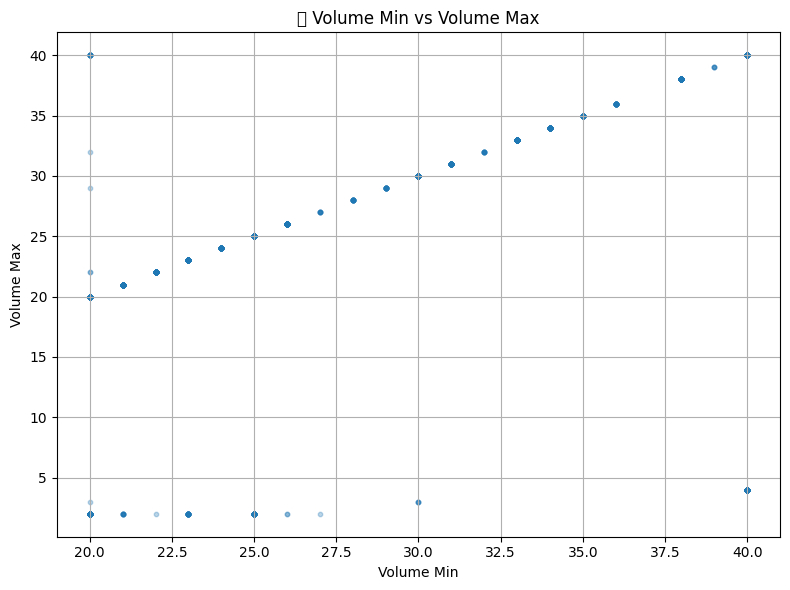

In [32]:
import matplotlib.pyplot as plt

# Drop rows with NaNs in either volume column
volume_df = df[['volume_min', 'volume_max']].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(volume_df['volume_min'], volume_df['volume_max'], alpha=0.3, s=10)
plt.xlabel("Volume Min")
plt.ylabel("Volume Max")
plt.title("📦 Volume Min vs Volume Max")
plt.grid(True)
plt.tight_layout()
plt.show()


⏱️ Top Frequency Tags:
frequency_tag
5 Day      101533
NaN         76780
BalMnth     14726
Any Day      2633
Name: count, dtype: int64


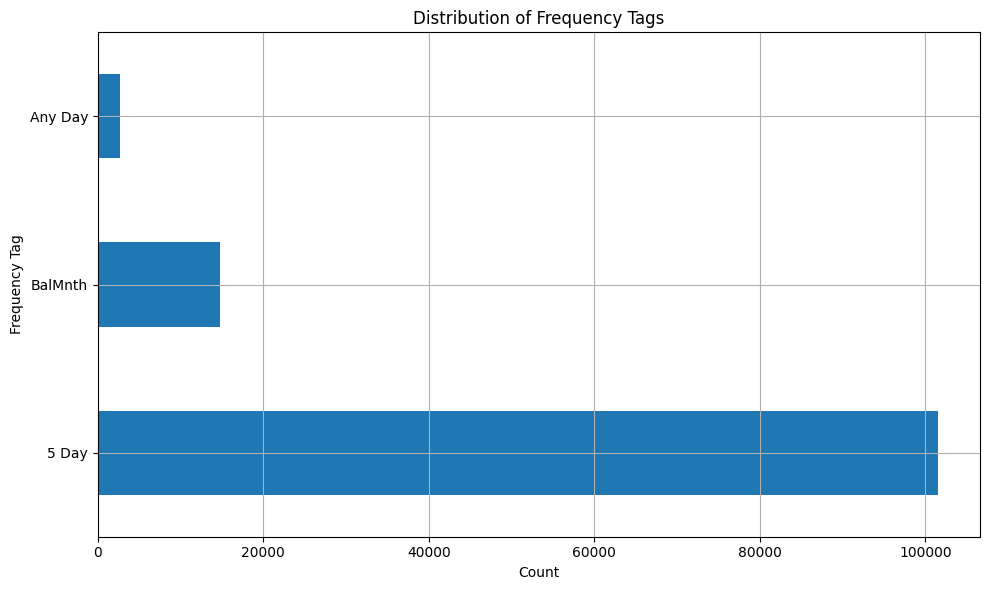

In [33]:
# Value counts
print("⏱️ Top Frequency Tags:")
print(df['frequency_tag'].value_counts(dropna=False))

# Bar chart
df['frequency_tag'].value_counts().plot(kind='barh', figsize=(10, 6), title="Distribution of Frequency Tags")
plt.xlabel("Count")
plt.ylabel("Frequency Tag")
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
# Ensure datetime format
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

# Calculate duration
df['duration_days'] = (df['end_date'] - df['start_date']).dt.days

# Drop NaNs
freq_duration = df[['frequency_tag', 'duration_days']].dropna()

# Group by frequency_tag and compute average duration
duration_by_tag = freq_duration.groupby('frequency_tag')['duration_days'].agg(['mean', 'median', 'count']).sort_values(by='count', ascending=False)

print("📏 Average Duration by Frequency Tag:")
print(duration_by_tag)


📏 Average Duration by Frequency Tag:
                    mean  median   count
frequency_tag                           
5 Day          -2.745448     4.0  100235
BalMnth        -2.656871     4.0   14496
Any Day        54.405384     4.0    2526


In [36]:
# Check how many rows have start_date after end_date
invalid_duration = df[(df['start_date'] > df['end_date'])]
print(f"❌ Rows with start_date > end_date: {len(invalid_duration)}")

# Optional: View some
invalid_duration[['headline', 'start_date', 'end_date', 'frequency_tag']].sample(5)


❌ Rows with start_date > end_date: 26335


,headline,start_date,end_date,frequency_tag
118207,Asia 244: Platts HSFO 380cst FOB Straits 15-30...,2019-06-16,2019-06-01,NaN
29541,"Platts HSFO Med Crg CIF bss Malta 10-25, GLTD ...",2023-09-26,2023-09-25,Any Day
28433,"Platts HSFO 380cst FOB Straits 15-30, SINOPECF...",2023-10-23,2023-04-27,5 Day
81457,"Platts HSFO 380cst FOB Straits 15-30, GUNVORSG...",2020-11-27,2020-11-16,5 Day
69061,"Platts HSFO 380cst FOB Straits 15-30, VITOLSG ...",2021-06-29,2021-06-03,5 Day


# 📌 Pinned Task for Data Validation Phase

During the **data validation phase**, ensure to include the following cross-check:

## ✅ Validate `start_date` and `end_date` Using `frequency_tag`

### Objective:
Ensure the predicted time window (`end_date - start_date`) is consistent with the value of `frequency_tag`.

---

### 🎯 Guidelines:

| Frequency Tag | Expected Duration Range (Days)       | Notes |
|---------------|---------------------------------------|-------|
| `5 Day`       | ~5 days (±2 days)                     | Should mostly fall between 3–7 days |
| `BalMnth`     | 15–30 days                            | Represents "Balance of Month" |
| `Any Day`     | Flexible                              | Can vary widely |
| `NaN`         | Skip or handle separately             | Unspecified – needs cautious handling |

---

### 🚨 Flag Conditions:

- `start_date > end_date`
- `duration` significantly deviates from the expected range of the `frequency_tag`

---

### 🔧 Example Implementation Pseudocode:
```python
df["duration"] = (df["end_date"] - df["start_date"]).dt.days
mask_invalid_5day = (df["frequency_tag"] == "5 Day") & ((df["duration"] < 2) | (df["duration"] > 8))
mask_invalid_balmnth = (df["frequency_tag"] == "BalMnth") & ((df["duration"] < 10) | (df["duration"] > 35))


In [45]:
import pandas as pd
import random
from IPython.display import display, Markdown

# === Step 1: Filter valid rows in the final dataset ===
valid_final = df_final[df_final['start_date'] <= df_final['end_date']]

# === Step 2: Find shared headlines between initial and valid final dataset ===
common_valid_headlines = set(df_initial['headline']).intersection(set(valid_final['headline']))
print(f"✅ Valid common headlines: {len(common_valid_headlines)}")

# === Step 3: Sample 5 random headlines ===
sampled_headlines = random.sample(sorted(common_valid_headlines), 5)

# === Step 4: Loop through each and display comparison ===
for i, headline in enumerate(sampled_headlines, 1):
    display(Markdown(f"### 🔍 Sample #{i} — Headline:\n`{headline}`"))

    initial_row = df_initial[df_initial['headline'] == headline]
    final_row = df_final[df_final['headline'] == headline]

    comparison_df = pd.DataFrame({
        "Initial Dataset": initial_row.iloc[0] if not initial_row.empty else "Not found",
        "Final Dataset": final_row.iloc[0] if not final_row.empty else "Not found"
    }).T

    display(comparison_df)


✅ Valid common headlines: 143661


### 🔍 Sample #1 — Headline:
`Platts HSFO 380cst FOB Straits 15-30, TOTALSG lowers offer Dec 21-Dec 25 100% MOPS 380 5 Day $5.75  for 20-20 "TotalEner`

,action_type,end_date,frequency_tag,grade,headline,id,incoterm,location,party,price,price_basis,start_date,updatedDate,volume_max,volume_min
Initial Dataset,NaN,NaN,NaN,NaN,"Platts HSFO 380cst FOB Straits 15-30, TOTALSG ...",4871469b-b048-4514-95bb-b254e3b9f66a,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-06T08:28:58.496Z,NaN,NaN
Final Dataset,Lower,2024-12-25,5 Day,380.0,"Platts HSFO 380cst FOB Straits 15-30, TOTALSG ...",NaN,FOB,Straits,TOTALSG,5.75,MOPS 380,2024-12-21,2024-12-06,20.0,20.0


### 🔍 Sample #2 — Headline:
`Platts HSFO 380cst FOB Straits 15-30, MIPCO raises bid Oct 4-Oct 8 100% MOPS 380 5 Day $6.00  for 40-40 "INCO" OCO  8:18`

,action_type,end_date,frequency_tag,grade,headline,id,incoterm,location,party,price,price_basis,start_date,updatedDate,volume_max,volume_min
Initial Dataset,NaN,NaN,NaN,NaN,"Platts HSFO 380cst FOB Straits 15-30, MIPCO ra...",f91e5410-f93f-4bf2-bf42-5f77c92a7dbc,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-13T08:18:00.191Z,NaN,NaN
Final Dataset,Raise,2021-10-22,5 Day,380.0,"Platts HSFO 380cst FOB Straits 15-30, MIPCO ra...",NaN,FOB,Straits,MIPCO,6.0,MOPS 380,2021-10-14,2021-09-13,40.0,40.0


...

,action_type,end_date,frequency_tag,grade,headline,id,incoterm,location,party,price,price_basis,start_date,updatedDate,volume_max,volume_min
Initial Dataset,NaN,NaN,NaN,NaN,Asia 567: Platts HSFO 180cst FOB Straits 15-30...,1689c41e-9868-48d4-94e5-da48130359a1,NaN,NaN,NaN,NaN,NaN,NaN,2017-11-13T08:08:25Z,NaN,NaN
Final Dataset,Lower,2017-12-12,5 Day,180.0,Asia 567: Platts HSFO 180cst FOB Straits 15-30...,NaN,FOB,Asia,CCMA,2.0,MOPS 180,2017-12-08,2017-11-13,20.0,20.0


### 🔍 Sample #4 — Headline:
`Platts HSFO 380CST: Jan 19 - Jan 23 pegged at MOPS -0.45, Jan Avg -0.64, Feb Avg 0.36, Flat Price 301.36`

,action_type,end_date,frequency_tag,grade,headline,id,incoterm,location,party,price,price_basis,start_date,updatedDate,volume_max,volume_min
Initial Dataset,NaN,NaN,NaN,NaN,Platts HSFO 380CST: Jan 19 - Jan 23 pegged at ...,6d1a01e8-7d70-4703-9955-1203b9ef41de,NaN,NaN,NaN,NaN,NaN,NaN,2020-12-30T07:37:48.775Z,NaN,NaN
Final Dataset,No Trade,2020-01-23,NaN,380.0,Platts HSFO 380CST: Jan 19 - Jan 23 pegged at ...,NaN,NaN,NaN,GLENCORESG,348.80607,NaN,2020-01-19,2020-12-30,NaN,NaN


### 🔍 Sample #5 — Headline:
`Platts HSFO 380cst FOB Straits 15-30, TRAFI bids Jul 18-Jul 22 100% MOPS 380 5 Day $2.00  for 40-40 OCO  7:57:10.885 GMT`

,action_type,end_date,frequency_tag,grade,headline,id,incoterm,location,party,price,price_basis,start_date,updatedDate,volume_max,volume_min
Initial Dataset,NaN,NaN,NaN,NaN,"Platts HSFO 380cst FOB Straits 15-30, TRAFI bi...",6ce5acdc-a876-4719-8038-545b386e34fc,NaN,NaN,NaN,NaN,NaN,NaN,2024-07-03T07:57:10.919Z,NaN,NaN
Final Dataset,Bid,2024-07-22,5 Day,380.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI bi...",NaN,FOB,Straits,TRAFI,2.0,MOPS 380,2024-07-18,2024-07-03,40.0,40.0


In [47]:
import pandas as pd
from IPython.display import display, HTML

# === Define the side-by-side comparison manually ===
data = {
    "Field": [
        "headline", "updatedDate", "start_date", "end_date", "action_type",
        "party", "price", "price_basis", "grade", "incoterm",
        "location", "volume_min", "volume_max", "frequency_tag"
    ],
    "Initial Dataset": [
        "Platts HSFO 380cst FOB Straits 15-30, TRAFI bids Jul 18-Jul 22 100% MOPS 380 5 Day $2.00 for 40-40 OCO 7:57:10.885 GMT",
        "2024-07-03T07:57:10.919Z", None, None, None, None, None, None, None, None, None, None, None, None
    ],
    "Final Dataset": [
        "Platts HSFO 380cst FOB Straits 15-30, TRAFI bids Jul 18-Jul 22 100% MOPS 380 5 Day $2.00 for 40-40 OCO 7:57:10.885 GMT",
        "2024-07-03", "2024-07-18", "2024-07-22", "Bid", "TRAFI", 2.0, "MOPS 380", 380.0, "FOB",
        "Straits", 40.0, 40.0, "5 Day"
    ]
}

# === Create DataFrame and display ===
comparison_df = pd.DataFrame(data)
display(HTML(comparison_df.to_html(index=False)))


Field,Initial Dataset,Final Dataset
headline,"Platts HSFO 380cst FOB Straits 15-30, TRAFI bids Jul 18-Jul 22 100% MOPS 380 5 Day $2.00 for 40-40 OCO 7:57:10.885 GMT","Platts HSFO 380cst FOB Straits 15-30, TRAFI bids Jul 18-Jul 22 100% MOPS 380 5 Day $2.00 for 40-40 OCO 7:57:10.885 GMT"
updatedDate,2024-07-03T07:57:10.919Z,2024-07-03
start_date,None,2024-07-18
end_date,None,2024-07-22
action_type,None,Bid
party,None,TRAFI
price,None,2.0
price_basis,None,MOPS 380
grade,None,380.0
incoterm,None,FOB
